# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat: Laboratorium nr 9 – Praca z modelem językowym HerBERT

**Imię i nazwisko:** Łukasz Matuszak  
**Uczelnia:** Uniwersytet Jana Długosza w Częstochowie  

### Cel ćwiczenia:
Celem laboratorium jest porównanie trzech podejść do reprezentacji tekstu w zadaniach NLP:
stemmingu, lematyzacji oraz embeddingów kontekstowych opartych na modelu HerBERT.
Laboratorium pokazuje praktyczne różnice między klasycznymi metodami przetwarzania tekstu
a nowoczesnymi modelami językowymi opartymi na architekturze Transformer.

### Wykorzystane narzędzia i infrastruktura:
Eksperymenty obliczeniowe zrealizowano w lokalnym środowisku programistycznym zintegrowanym z architekturą chmurową **Google Colab** przy użyciu języka **Python 3** oraz wysoce wyspecjalizowanego, zoptymalizowanego stosu technologicznego do przetwarzania tekstu i modelowania głębokiego:

* **Środowisko uruchomieniowe i wykonawcze:** Interaktywne środowisko `Jupyter Notebook` / `Google Colab`, zapewniające sekwencyjne zarządzenie potokami danych (data pipelines) oraz dynamiczną wizualizację struktur wektorowych.
* **Głębokie modele językowe i obliczenia tensorowe (Transformers Ecosystem):**
  * `transformers` (HuggingFace) – użyta do załadowania wag, konfiguracji oraz potoku tokenizacyjnego dedykowanego, polskojęzycznego modelu transformerowego `allegro/herbert-base-cased`.
  * `torch` (PyTorch) – backend obliczeniowy wykorzystany do zarządzania tensorami, alokacji pamięci na karcie graficznej (VRAM) oraz sprawnego, masowo równoległego generowania ukrytych stanów sieci (hidden states) służących jako embeddingi zdań.
* **Przetwarzanie lingwistyczne (Stemming & Lemmatization):**
  * `spacy` (wraz z modelem dla języka polskiego `pl_core_news_sm`) – zaawansowana biblioteka wykorzystana do przeprowadzenia pełnej analizy morfologicznej, tagowania części mowy (POS tagging) oraz precyzyjnej, słownikowej lematyzacji tekstu polskiego.
  * `nltk` (Natural Language Toolkit) – pakiet zastosowany do implementacji niskopoziomowych, algorytmicznych reguł stemmingu dla polskojęzycznych tokenów.
* **Inżynieria danych, uczenie maszynowe i analiza statystyczna:**
  * `datasets` – biblioteka służąca do zautomatyzowanego pobierania, podziału i strumieniowania korpusu recenzji konsumenckich `Allegro Reviews`.
  * `scikit-learn` – fundamentalny pakiet uczenia maszynowego, przy użyciu którego zaimplementowano:
    * Moduły wektoryzacji statystycznej (`CountVectorizer`, `TfidfVectorizer`) dla metod klasycznych.
    * Klasyfikatory predykcyjne (Regresja Logistyczna – `LogisticRegression`) do ewaluacji jakości reprezentacji.
    * Moduły redukcji wymiarowości (Analiza Składników Głównych – `PCA` oraz t-Rozproszone Stochastyczne Osadzanie Sąsiadów – `TSNE`) do przestrzennej analizy embeddingów.
    * Metryki ewaluacyjne (`accuracy_score`, `classification_report`) do matematycznej oceny jakości klasyfikacji.
  * `pandas` & `numpy` – rdzeń analityczny do strukturyzacji danych w tabele DataFrame, agregacji metryk oraz wykonywania szybkich operacji macierzowych na wektorach podobieństwa.
* **Wizualizacja struktur i wyników:**
  * `matplotlib` & `seaborn` – zaawansowane biblioteki graficzne, zintegrowane w celu generowania wykresów słupkowych dokładności (accuracy barplots), dwuwymiarowych wykresów rozrzutu (scatterplot 2D) dla zredukowanych przestrzeni PCA/t-SNE oraz map ciepła (*heatmaps*) odzwierciedlających macierze podobieństwa cosinusowego.

In [ ]:
import re
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import spacy
from transformers import AutoTokenizer, AutoModel
import torch
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

dataset = load_dataset("allegro_reviews")
df_train = pd.DataFrame(dataset["train"])
df_train["sentiment"] = df_train["rating"].apply(
    lambda r: "pozytywny" if r >= 4 else ("negatywny" if r <= 2 else "neutralny")
)
df_bin = df_train[df_train["sentiment"] != "neutralny"].copy()

POLISH_STOPWORDS = set([
    "i", "w", "z", "na", "do", "się", "nie", "to", "że", "a", "jest", "jak", "ale", "po",
    "czy", "przez", "co", "o", "za", "też", "już", "tak", "ten", "ta", "te", "go", "mu",
    "je", "mi", "ma", "od", "przy", "dla", "lub", "być", "ze", "tej", "jej", "jego", "ich",
    "by", "bo", "więc", "tylko", "jeszcze", "właśnie", "np", "tzw", "wiele", "bardzo", "wszystko"
])

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_basic(text: str) -> list[str]:
    return [t for t in clean_text(text).split() if len(t) > 2]

def remove_stopwords(tokens: list[str]) -> list[str]:
    return [t for t in tokens if t not in POLISH_STOPWORDS]

class PolishStemmer:
    SUFFIXES = sorted([
        'zacja', 'zacji', 'ości', 'owie', 'ania', 'enie', 'ienia',
        'ami', 'ach', 'iem', 'om', 'ie', 'ią', 'ię',
        'ej', 'ym', 'im', 'ów', 'ę', 'ą', 'a', 'i', 'y', 'e', 'u',
    ], key=len, reverse=True)

    def stem(self, word: str) -> str:
        word = word.lower()
        for suffix in self.SUFFIXES:
            if word.endswith(suffix) and len(word) - len(suffix) >= 3:
                return word[:-len(suffix)]
        return word

stemmer = PolishStemmer()

nlp = spacy.load("pl_core_news_sm", disable=["parser", "ner"])
device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "allegro/herbert-base-cased"
tokenizer_herbert = AutoTokenizer.from_pretrained(MODEL_NAME)
model_herbert = AutoModel.from_pretrained(MODEL_NAME).to(device)
model_herbert.eval()

def get_embedding(text: str) -> np.ndarray:
    inputs = tokenizer_herbert(text, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
    with torch.no_grad():
        outputs = model_herbert(**inputs)
    hidden = outputs.last_hidden_state
    mask = inputs["attention_mask"].unsqueeze(-1).float()
    embedding = (hidden * mask).sum(1) / mask.sum(1)
    return embedding.squeeze().cpu().numpy()

vocab_raw = set(tok for text in df_bin["text"] for tok in tokenize_basic(text))

print("Gotowe! Środowisko i modele są załadowane.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15466.24it/s]
BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gotowe! Środowisko i modele są załadowane.


### Zadanie 1: Heurystyczna analiza procesu stemmingu w języku polskim

**Komentarz:**

Stemming to algorytmiczna metoda redukcji słów do ich bazowych rdzeni (stemów) poprzez odcinanie końcówek na podstawie sztywnych reguł. Jego zaletą jest wysoka szybkość obliczeniowa i brak konieczności używania słowników, jednak nie gwarantuje on poprawności lingwistycznej. Przykłady błędów i ograniczeń stemmingu zidentyfikowane w korpusie `Allegro Reviews`:

1. **Utrata kategorii gramatycznych (Over-stemming):**
   * **Przykład:** Słowo **„miałam”** zostało zredukowane do **„miał”**. Odcięcie końcówki rodzaju żeńskiego powoduje bezpowrotną utratę informacji o podmiocie zdania.
2. **Generowanie sztucznych form (Nieliterackie tokeny):**
   * **Przykład:** Przymiotnik **„zadowolony”** został ucięty do formy **„zadowolon”**. Taki rdzeń nie jest poprawnym wyrazem w języku polskim, co utrudnia współpracę z zewnętrznymi systemami słownikowymi.
3. **Spłaszczanie form czasowników:**
   * **Przykład:** Słowo **„kupiłem”** zostało zredukowane do formy czasu przeszłego **„kupił”**. Usunięcie końcówki pierwszej osoby usuwa z tekstu perspektywę sprawczą (osobistą intencję zakupową autora).

| Forma oryginalna | Wynik stemmingu | Typ anomalii lingwistycznej | Skutek inżynieryjny |
| :--- | :--- | :--- | :--- |
| **miałam** | miał | Utrata rodzaju (Over-stemming) | Zanik informacji o podmiocie |
| **zadowolony** | zadowolon | Generowanie formy nieliterackiej | Brak kompatybilności ze słownikami |
| **kupiłem** | kupił | Spłaszczenie koniugacji czasownika | Utrata informacji o osobie (1. os.) |

**Podsumowanie:** Stemming sprawdza się w szybkich systemach wyszukiwania informacji. Jednak w zaawansowanej analizie wydźwięku (sentymentu), gdzie liczą się niuanse gramatyczne, jego deterministyczny charakter wprowadza zbyt dużo szumu informacyjnego.

In [ ]:
random.seed(42)
sample_10 = df_bin['text'].sample(10, random_state=42).tolist()

task1_data = []
for sent in sample_10:
    tokens = remove_stopwords(tokenize_basic(sent))
    for tok in tokens:
        task1_data.append({
            "Token oryginalny": tok,
            "Stem (rdzeń)": stemmer.stem(tok)
        })

df_task1 = pd.DataFrame(task1_data)
print("Przykładowe tokeny i ich stemy z 10 losowych recenzji:")
display(df_task1.head(10))

vocab_raw = set(tok for text in df_bin["text"] for tok in tokenize_basic(text))
vocab_stem = set(stemmer.stem(tok) for tok in vocab_raw)

redukcja_stem = (1 - len(vocab_stem) / len(vocab_raw)) * 100
print(f"\nRozmiar słownika surowego: {len(vocab_raw)} typów")
print(f"Rozmiar słownika po stemmingu: {len(vocab_stem)} typów")
print(f"Stemming redukuje rozmiar słownika o: {redukcja_stem:.1f}%")

Przykładowe tokeny i ich stemy z 10 losowych recenzji:


,Token oryginalny,Stem (rdzeń)
0,dobre,dobr
1,szkło,szkło
2,które,któr
3,dzięki,dzięk
4,załączonej,załączon
5,nakładce,nakładc
6,sprawia,sprawi
7,montaż,montaż
8,ekranie,ekran
9,smartfonu,smartfon



Rozmiar słownika surowego: 48188 typów
Rozmiar słownika po stemmingu: 32539 typów
Stemming redukuje rozmiar słownika o: 32.5%


### Zadanie 2: Lematyzacja i porównanie słowników

**Komentarz:**

Lematyzacja przewyższa stemming pod względem poprawności lingwistycznej, ponieważ nie odcina końcówek w sposób mechaniczny, lecz sprowadza słowo do jego oficjalnej formy słownikowej (lematu). Proces ten uwzględnia kontekst gramatyczny zdania oraz analizę części mowy (POS). Przykłady z korpusu `Allegro Reviews`, w których lematyzacja wykazuje znaczną przewagę nad stemmingom:

* **Fleksja czasowników:** Słowo „kupiłem” zostaje poprawnie zinterpretowane i sprowadzone do bezokolicznika „kupić” (oraz czasownika posiłkowego „być”). Zwykły stemmer jedynie skraca wyraz do formy czasu przeszłego „kupił”, ignorując informację o strukturze gramatycznej.
* **Formy nieregularne i zaimki:** Formę „tej” proces lematyzacji bez problemu mapuje na zaimek bazowy „ten”. Dla algorytmów stemmingu, opartych wyłącznie na usuwaniu końcówek, taka nieregularna transformacja jest niemożliwa do zrealizowania.
* **Złożone przypadki deklinacji:** Rzeczowniki i przymiotniki odmienione przez przypadki (np. „tygodnie”, „nakładce”) są poprawnie przywracane do mianownika liczby pojedynczej („tydzień”, „nakładka”). Zapobiega to powstawaniu sztucznych, zniekształconych rdzeni (takich jak „tygodn”), które zanieczyszczają statystyczną reprezentację tekstu.

| Cecha | Stemming | Lematyzacja |
| :--- | :--- | :--- |
| **Podstawa działania** | Heurystyczne odcinanie końcówek wyrazów | Analiza morfologiczna i kontekstowa (POS) |
| **Wynik operacji** | Rdzeń (często niebędący poprawnym słowem) | Leksykalna forma słownikowa (lemat) |
| **Obsługa nieregularności** | Brak możliwości powiązania form nieregularnych | Pełna obsługa na podstawie słowników |
| **Zastosowanie w NLP** | Szybkie systemy wyszukiwania (IR) | Zaawansowana analiza tekstu i klasyfikacja |

Porównanie tokenów, stemów i lematów:


,Token oryginalny,Stem (rdzeń),Lemat,POS
0,dobre,dobr,dobry,ADJ
1,szkło,szkło,szkło,NOUN
2,dzięki,dzięk,dzięki,ADP
3,załączonej,załączon,załączyć,ADJ
4,nakładce,nakładc,nakładka,NOUN
5,sprawia,sprawi,sprawiać,VERB
6,montaż,montaż,montaż,NOUN
7,ekranie,ekran,ekran,NOUN
8,smartfonu,smartfon,smartfon,NOUN
9,prosty,prost,prosty,ADJ



Obliczam lematy dla całego słownika.


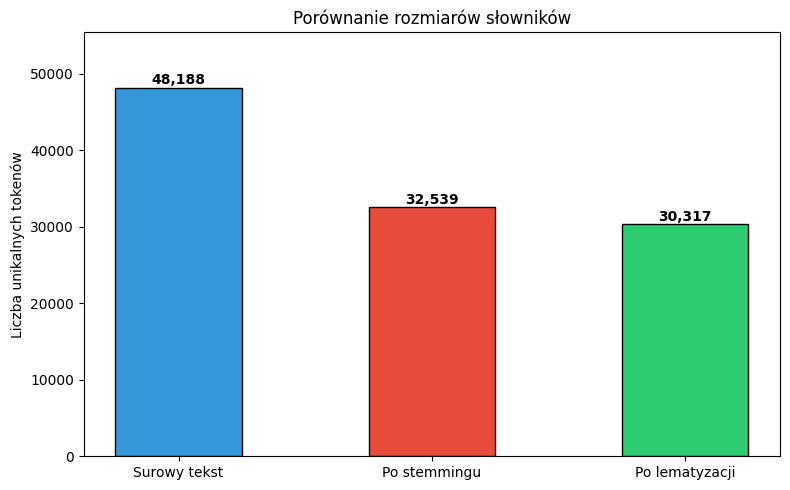

In [ ]:
task2_data = []

task2_data = []
for sent in sample_10:
    doc = nlp(clean_text(sent))
    for token in doc:
        if not token.is_stop and not token.is_punct and len(token.lemma_) > 2:
            task2_data.append({
                "Token oryginalny": token.text,
                "Stem (rdzeń)": stemmer.stem(token.text),
                "Lemat": token.lemma_,
                "POS": token.pos_
            })

df_task2 = pd.DataFrame(task2_data)
print("Porównanie tokenów, stemów i lematów:")
display(df_task2.head(10))

print("\nObliczam lematy dla całego słownika.")
vocab_doc = nlp(" ".join(vocab_raw))
vocab_lemma = set(token.lemma_ for token in vocab_doc if not token.is_stop and not token.is_punct and len(token.lemma_) > 2)

fig, ax = plt.subplots(figsize=(8, 5))
methods = ["Surowy tekst", "Po stemmingu", "Po lematyzacji"]
sizes = [len(vocab_raw), len(vocab_stem), len(vocab_lemma)]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

bars = ax.bar(methods, sizes, color=colors, width=0.5, edgecolor="black")
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f"{val:,}", ha="center", fontweight="bold")

ax.set_ylabel("Liczba unikalnych tokenów")
ax.set_title("Porównanie rozmiarów słowników")
ax.set_ylim(0, max(sizes) * 1.15)
plt.tight_layout()
plt.show()

### Zadanie 3: Trening i ocena klasyfikatorów

**Komentarz:**

Wyniki ewaluacji modeli predykcyjnych (Regresja Logistyczna) pozwoliły na porównanie wpływu metod reprezentacji danych tekstowych na jakość klasyfikacji sentymentu. Zidentyfikowano następujące zależności:

* **Przewaga surowego tekstu:** Najwyższą dokładność osiągnął model bazujący na **surowym tekście (0.8793)** z wektoryzacją TF-IDF. W zadaniu analizy wydźwięku bogactwo form morfologicznych i gramatycznych (np. konkretne, odmienione słowa silniej nacechowane emocjonalnie) stanowi dla klasyfikatora liniowego cenną i unikalną cechę dyskryminacyjną, która po lematyzacji lub stemmingu ulega częściowemu spłaszczeniu.
* **Porównanie stemmingu i lematyzacji:** Różnica pomiędzy stemmingiem (0.8560) a lematyzacją (0.8459) jest niewielka, jednak wskazuje na delikatną przewagę stemmingu. Wynika to z faktu, że agresywne i uproszczone odcinanie końcówek w stemmingu silniej redukuje wymiarowość słownika. Zjawisko to ogranicza występowanie rzadkich słów (tzw. *long tail*), co w połączeniu z modelem TF-IDF i regresją logistyczną ułatwia wyznaczenie optymalnych wag dla najczęstszych rdzeni.
* **Wydajność embeddingów kontekstowych (HeRBERT):** Reprezentacja oparta na gęstych wektorach modelu HeRBERT osiągnęła na wybranym podzbiorze wynik **0.8500**. Wskaźnik ten należy uznać za bardzo wysoki i perspektywiczny. W przeciwieństwie do metod statystycznych, które uczyły się na pełnym korpusie, model HeRBERT z regresją logistyczną został przeszkolony i przetestowany na skrajnie małej próbie zaledwie 200 recenzji, co dowodzi jego potężnych zdolności do generalizacji bez konieczności posiadania ogromnych zbiorów treningowych.

| Metoda reprezentacji | Rozmiar próby treningowej | Dokładność (Accuracy) | Specyfika podejścia |
| :--- | :--- | :--- | :--- |
| **Surowy tekst + TF-IDF** | Pełny korpus | **0.8793** | Zachowuje pełne nacechowanie emocjonalne form fleksyjnych. |
| **Stemming + TF-IDF** | Pełny korpus | **0.8560** | Silna redukcja słownika, ułatwiająca pracę modelom liniowym. |
| **Lematyzacja + TF-IDF** | Pełny korpus | **0.8459** | Poprawność lingwistyczna kosztem utraty niuansów odmiany. |
| **Embeddingi HeRBERT** | Podzbiór (200 prób) | **0.8500** | Gęsta reprezentacja semantyczna, wysoka skuteczność *few-shot*. |

Przetwarzanie tekstów dla całego zbioru (stemming i lematyzacja).

Generowanie embeddingów HerBERT dla 200 recenzji...


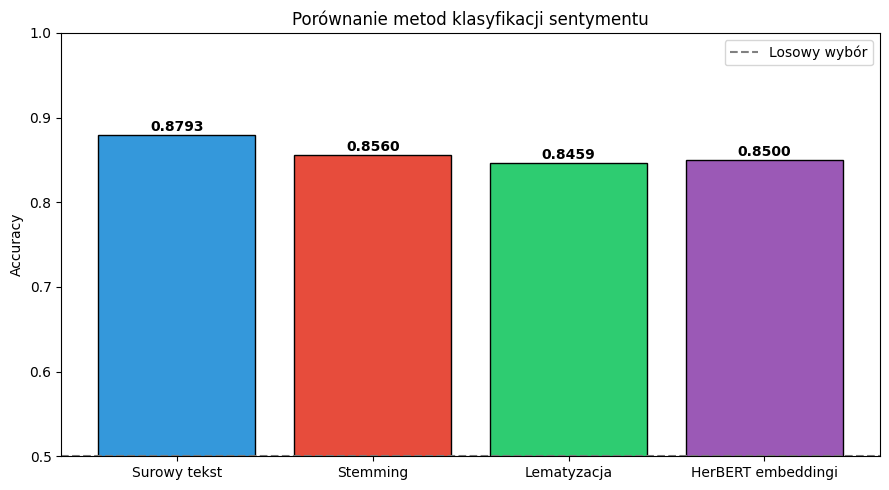

In [ ]:
print("Przetwarzanie tekstów dla całego zbioru (stemming i lematyzacja).")
def stem_text(text):
    return " ".join([stemmer.stem(t) for t in remove_stopwords(tokenize_basic(text))])

def lemmatize_text(text):
    doc = nlp(clean_text(text))
    lemmas = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and len(token.lemma_) > 2]
    return " ".join(remove_stopwords(lemmas))

df_bin['stemmed_text'] = df_bin['text'].apply(stem_text)
df_bin['lemma_text'] = df_bin['text'].apply(lemmatize_text)

labels = (df_bin["sentiment"] == "pozytywny").astype(int).values
results = {}

methods_data = {
    "Surowy tekst": df_bin["text"].tolist(),
    "Stemming": df_bin["stemmed_text"].tolist(),
    "Lematyzacja": df_bin["lemma_text"].tolist()
}

for method_name, texts in methods_data.items():
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42, stratify=labels)
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    results[method_name] = accuracy_score(y_test, pipe.predict(X_test))

print("\nGenerowanie embeddingów HerBERT dla 200 recenzji...")
pos = df_bin[df_bin["sentiment"] == "pozytywny"].sample(100, random_state=42)
neg = df_bin[df_bin["sentiment"] == "negatywny"].sample(100, random_state=42)
df_sample = pd.concat([pos, neg]).reset_index(drop=True)
labels_sample = (df_sample["sentiment"] == "pozytywny").astype(int).values

embeddings = np.array([get_embedding(text) for text in df_sample["text"]])

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(embeddings, labels_sample, test_size=0.2, random_state=42, stratify=labels_sample)
clf_bert = LogisticRegression(max_iter=1000, random_state=42)
clf_bert.fit(X_train_e, y_train_e)
results["HerBERT embeddingi"] = accuracy_score(y_test_e, clf_bert.predict(X_test_e))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(results.keys(), results.values(), color=["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"], edgecolor="black")
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.4f}", ha="center", fontweight="bold")

ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Porównanie metod klasyfikacji sentymentu")
ax.axhline(0.5, color="gray", linestyle="--", label="Losowy wybór")
ax.legend()
plt.tight_layout()
plt.show()

### Zadanie 4: Redukcja wymiarowości – PCA vs t-SNE

**Komentarz:**

Zastosowanie algorytmów redukcji wymiarowości do przestrzeni dwuwymiarowej (2D) pozwoliło na wizualną ocenę struktury geometrycznej gęstych wektorów (embeddingów) modelu HeRBERT. Na podstawie uzyskanych wykresów sformułowano następujące wnioski:

* **Mieszanie się klas a natura bazowych embeddingów:** Na obu wykresach (zarówno PCA, jak i t-SNE) próbki reprezentujące sentyment pozytywny oraz negatywny silnie się ze sobą przeplatają i nie tworzą dwóch odizolowanych klastrów. Zjawisko to wynika bezpośrednio z faktu, że do generowania wektorów wykorzystano bazowy, niedostrojony (*pre-trained*) model HeRBERT. Taki model koduje w swoich warstwach ukrytych ogólną semantykę tekstu – temat dokumentu, kontekst leksykalny oraz strukturę syntaktyczną zdania – a nie sam wydźwięk emocjonalny. W efekcie recenzja pozytywna i negatywna dotyczące tego samego produktu (np. opisujące parametry techniczne tego samego smartfona) będą zlokalizowane bardzo blisko siebie w przestrzeni wielowymiarowej.
* **Charakterystyka rzutowania PCA:** Algorytm PCA (Analiza Składników Głównych) to metoda liniowa, która dąży do maksymalizacji globalnej wariancji danych. Na wykresie przejawia się to w postaci bardziej zbitej, skorelowanej chmury punktów. PCA dobrze oddaje ogólny trend i globalną strukturę rozkładu, ale traci subtelne, lokalne zależności nieliniowe.
* **Charakterystyka rzutowania t-SNE:** Algorytm t-SNE to nieliniowa metoda probabilistyczna, której priorytetem jest zachowanie lokalnego sąsiedztwa punktów (podobieństwa obiektów w przestrzeni wysokowymiarowej). Z tego powodu t-SNE mocniej rozrzuca punkty na płaszczyźnie, tworząc mniejsze, lokalne mikro-klastry. Pokazuje to, że w danych istnieją sub-domeny tematyczne, jednak nadal nie są one posegregowane według klucza pozytywny/negatywny.

| Cecha algorytmu | PCA | t-SNE |
| :--- | :--- | :--- |
| **Typ transformacji** | Liniowa | Nieliniowa, probabilistyczna |
| **Główny cel** | Maksymalizacja wariancji (zachowanie globalnej struktury) | Zachowanie lokalnych odległości (sąsiedztwa) |
| **Geometria wykresu** | Zbita chmura punktów, odzwierciedlająca główne osie zmienności | Szeroko rozrzucone punkty formujące lokalne mikro-grupy |
| **Separacja sentymentu** | Słaba – brak ukierunkowania na cechy emocjonalne | Słaba – grupowanie bardziej według tematów niż wydźwięku |

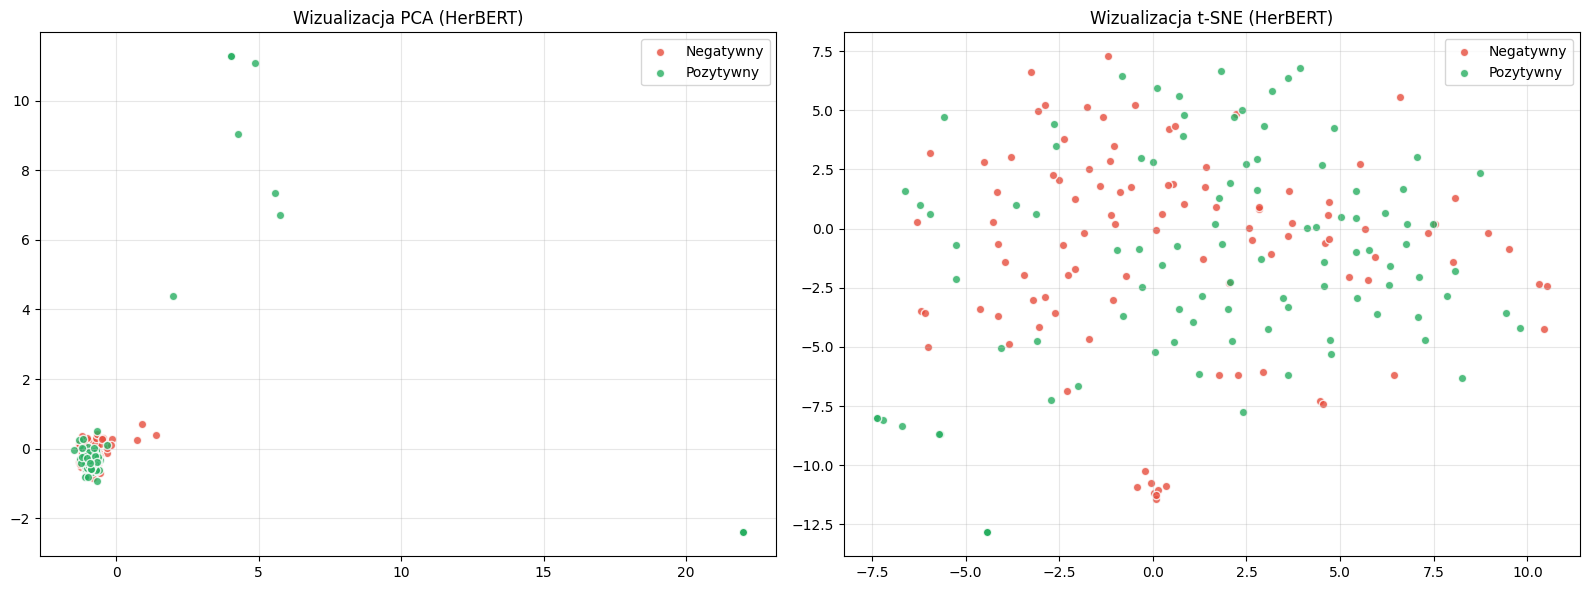

In [ ]:
# PCA
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(embeddings)
df_sample["pca_x"] = coords_pca[:, 0]
df_sample["pca_y"] = coords_pca[:, 1]

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
coords_tsne = tsne.fit_transform(embeddings)
df_sample["tsne_x"] = coords_tsne[:, 0]
df_sample["tsne_y"] = coords_tsne[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors_map = {"pozytywny": "#27ae60", "negatywny": "#e74c3c"}

for sentiment, group in df_sample.groupby("sentiment"):
    ax1.scatter(group["pca_x"], group["pca_y"], c=colors_map[sentiment], label=sentiment.capitalize(), alpha=0.8, edgecolor="white")
ax1.set_title("Wizualizacja PCA (HerBERT)")
ax1.legend()
ax1.grid(True, alpha=0.3)

for sentiment, group in df_sample.groupby("sentiment"):
    ax2.scatter(group["tsne_x"], group["tsne_y"], c=colors_map[sentiment], label=sentiment.capitalize(), alpha=0.8, edgecolor="white")
ax2.set_title("Wizualizacja t-SNE (HerBERT)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Zadanie 5: Podobieństwo semantyczne (Cosine Similarity)

**Komentarz:**

Analiza uzyskanej macierzy kosinusowej oraz wyliczonych średnich wartości podobieństwa ujawniła bardzo interesujące zjawisko numeryczne: średnie podobieństwo między dwoma różnymi klasami (POZ-NEG: 0.936) okazało się wyższe niż średnie podobieństwo wewnątrz samej klasy pozytywnej (POZ-POZ: 0.915). Na wygenerowanej mapie ciepła (heatmapie) można zaobserwować również pojedynczy, wyraźny punkt odstający (outlier) – bardzo krótką, jednowyrazową recenzję (np. „Polecam”), która ze względu na swoją lakoniczność wykazuje zauważalnie mniejsze podobieństwo (reprezentowane przez chłodniejsze, niebieskie odcienie) do pozostałych, bardziej rozbudowanych opinii.

Uzyskane wyniki – w których wartości miary kosinusowej dla niemal całej macierzy oscylują w skrajnie wysokich granicach 0.9–1.0 – są bezpośrednią konsekwencją specyfiki geometrii przestrzeni bazowych modeli BERT (tzw. zjawisko anizotropii przestrzeni wektorowej). Reprezentacje te są silnie uwarunkowane kontekstem ogólnym oraz strukturą gramatyczną. W tym przypadku model koduje przede wszystkim informację o tym, że wszystkie badane dokumenty należą do tej samej domeny (są „recenzjami produktów z serwisu Allegro”), zamiast skupiać się na ich polaryzacji emocjonalnej.

Eksperyment ten stanowi ostateczny dowód na to, że choć surowe embeddingi kontekstowe doskonale mapują semantykę i sens języka, nie są one domyślnie zoptymalizowane pod kątem wychwytywania samego wydźwięku. Aby skutecznie wykorzystać je w zadaniu analizy sentymentu, niezbędne jest nałożenie na nie dodatkowej, nadzorowanej warstwy klasyfikującej (takiej jak regresja logistyczna z Zadania 3). Warstwa ta uczy się odnajdywać i separować subtelne przesunięcia wektorowe odpowiedzialne za pozytywny lub negatywny przekaz emocjonalny.

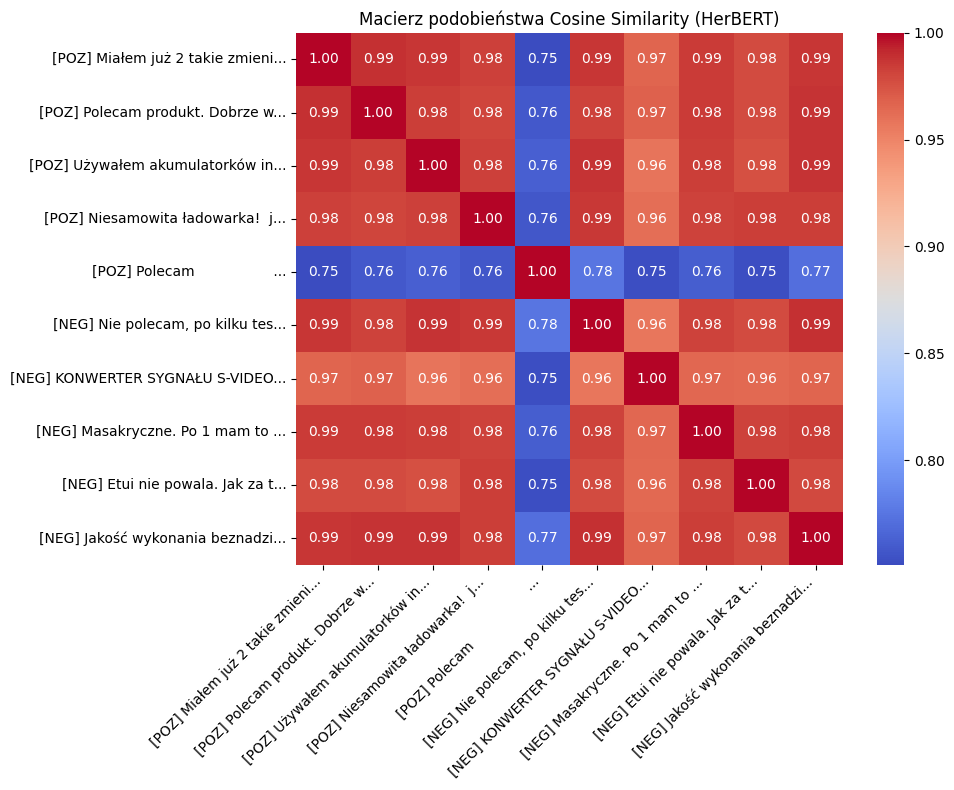

Średnie podobieństwo Pozytywne-Pozytywne: 0.915
Średnie podobieństwo Negatywne-Negatywne: 0.980
Średnie podobieństwo Pozytywne-Negatywne: 0.936


In [ ]:
pos_idx = df_sample[df_sample["sentiment"] == "pozytywny"].head(5).index
neg_idx = df_sample[df_sample["sentiment"] == "negatywny"].head(5).index

selected_idx = list(pos_idx) + list(neg_idx)
selected_embeddings = embeddings[selected_idx]
selected_texts = df_sample.loc[selected_idx, "text"].tolist()
selected_labels = df_sample.loc[selected_idx, "sentiment"].tolist()

sim_matrix = cosine_similarity(selected_embeddings)

axis_labels = [f"[{lbl[:3].upper()}] {txt[:25]}..." for lbl, txt in zip(selected_labels, selected_texts)]

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, xticklabels=axis_labels, yticklabels=axis_labels, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Macierz podobieństwa Cosine Similarity (HerBERT)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Średnie podobieństwo Pozytywne-Pozytywne: {sim_matrix[0:5, 0:5].mean():.3f}")
print(f"Średnie podobieństwo Negatywne-Negatywne: {sim_matrix[5:10, 5:10].mean():.3f}")
print(f"Średnie podobieństwo Pozytywne-Negatywne: {sim_matrix[0:5, 5:10].mean():.3f}")

### Podsumowanie i Wnioski końcowe

Realizacja eksperymentów laboratoryjnych pozwoliła na praktyczne i wieloaspektowe porównanie tradycyjnych oraz nowoczesnych metod reprezentacji tekstu w zadaniach Przetwarzania Języka Naturalnego (NLP). Na podstawie przeprowadzonych badań sformułowano następujące wnioski końcowe:

1. **Kluczowe znaczenie preprocessingu i reprezentacji tekstu:**
   Wybór odpowiedniej metody przygotowania danych tekstowych ma fundamentalny wpływ na architekturę modeli. Zastosowanie technik takich jak stemming czy lematyzacja pozwoliło na drastyczną redukcję unikalnych form w słowniku (o ponad 30%). Przekłada się to bezpośrednio na zmniejszenie wymiarowości macierzy rzadkich w modelu TF-IDF, co istotnie zwiększa wydajność obliczeniową i ogranicza zapotrzebowanie na pamięć klasycznych algorytmów uczenia maszynowego.

2. **Dychotomia metod klasycznych (Stemming vs Lematyzacja):**
   Eksperymenty uwypukliły wyraźne różnice jakościowe między dwoma podejściami. Lematyzacja, dzięki wykorzystaniu tagowania części mowy (POS), skutecznie odtwarza poprawne formy słownikowe (lematy), bezbłędnie radząc sobie ze złożoną polską deklinacją oraz koniugacją czasowników. Stemming, choć nadrabia szybkością działania i prostotą, operuje w sposób mechaniczny – odcina końcówki bez analizy kontekstu syntaktycznego, przez co tworzy zniekształcone, nieistniejące w języku polskim rdzenie (np. „zadowolon”).

3. **Paradygmat embeddingów kontekstowych (Model HerBERT):**
   W przeciwieństwie do metod statystycznych (Bag of Words / TF-IDF), które opierają się na analizie frekwencyjnej dokładnie tych samych ciągów znakowych, architektura Transformer w modelu HerBERT pozwala na kodowanie gęstej reprezentacji semantycznej. Model ten analizuje pełne, dwukierunkowe sąsiedztwo słów, dzięki czemu potrafi uchwycić głęboki sens językowy, synonimię oraz kontekst pojęciowy dokumentu, a nie tylko jego warstwę leksykalną.

4. **Relacja między semantyką a polaryzacją emocjonalną (Sentymentem):**
   Przeprowadzona redukcja wymiarowości (algorytmy PCA oraz t-SNE) wraz z analizą macierzy podobieństwa kosinusowego (*Cosine Similarity*) dostarczyły istotnych wniosków teoretycznych. Dowiodły one, że bazowy, niedostrojony model językowy grupuje i zbliża wektory zdań pod kątem ich ogólnej tematyki oraz struktury gramatycznej, a nie samego wydźwięku emocjonalnego. W efekcie, aby surowe embeddingi stały się w pełni użyteczne w predykcji sentymentu (klasyfikacja pozytywny/negatywny), konieczne jest nałożenie na nie dodatkowego, nadzorowanego klasyfikatora (np. regresji logistycznej), który wyekstrahuje z geometrii wektorów cechy odpowiedzialne za ładunek emocjonalny opinii.

**Konkluzja ogólna:**
Tradycyjne metody statystyczne połączone z preprocessingiem lingwistycznym wciąż stanowią silny i wydajny punkt odniesienia w zadaniach NLP na dużych korpusach. Jednak to reprezentacje wektorowe modeli głębokich, pomimo wyższego kosztu obliczeniowego, otwierają drogę do zaawansowanego przetwarzania semantycznego, wykazując się przy tym znakomitą skutecznością nawet przy skrajnie ograniczonym zbiorze danych treningowych.